# Entregable 4 - Neuronas Activas SAE por Clase

Notebook consolidado de entrega final para Situacion 2. Raiz evaluable unica: `/workspace/geovision-cali-hf/Entrega_Final/Situacion2`.

## Objetivo

Consolidar la interpretabilidad mecanica del SAE: sparsity, unidades activas medias, unidades muertas y top unidades por clase. Toda la evidencia final se referencia desde `sae_interpretabilidad/`.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

ROOT = Path('/workspace/geovision-cali-hf/Entrega_Final/Situacion2')
pd.set_option('display.max_colwidth', 160)


In [2]:
display(pd.read_csv(ROOT / 'sae_interpretabilidad/split_summary.csv'))


,split,n,recall_at_1,macro_recall,sparsity_ratio,recon_mse,active_units_mean,active_units_median,dead_units_pct
0,train,1000,0.981000,0.980846,0.880859,0.016192,122.000008,122.0,5.859375
1,val,265,0.483019,0.469614,0.880859,0.013364,122.000000,122.0,12.890625
2,test,235,0.548936,0.550672,0.880859,0.014307,121.999992,122.0,13.183594


## Interpretacion del Resumen por Split

El SAE mantiene una sparsity estable de `0.8809` en train, validacion y test. Esto equivale a cerca de `122` unidades activas de `1024` por muestra, lo que facilita interpretar que subconjuntos compactos de neuronas responden a patrones visuales/textuales. El porcentaje de unidades muertas en test (`13.18%`) es aceptable para una configuracion sparse: hay especializacion sin colapso masivo del diccionario.

In [3]:
top = pd.read_csv(ROOT / 'sae_interpretabilidad/top_units_by_class.csv')
test_top = top[top['split'] == 'test'].copy()
display(test_top.groupby('candidate_class').head(5))


,split,candidate_class,unit,mean_abs_activation,active_frequency
250,test,contaminacion_alta_NO2,485,0.106280,0.704545
251,test,contaminacion_alta_NO2,758,0.103570,0.681818
252,test,contaminacion_alta_NO2,600,0.101342,0.636364
253,test,contaminacion_alta_NO2,998,0.098260,0.636364
254,test,contaminacion_alta_NO2,618,0.090244,0.636364
275,test,contaminacion_alta_SO2,711,0.166366,0.820000
276,test,contaminacion_alta_SO2,432,0.154154,0.900000
277,test,contaminacion_alta_SO2,1,0.153927,0.740000
278,test,contaminacion_alta_SO2,692,0.152186,0.820000
279,test,contaminacion_alta_SO2,269,0.149023,0.800000


## Interpretacion por Clase

La tabla anterior lista las unidades con mayor activacion media por clase en test. La lectura correcta no es que una unidad sea una etiqueta semantica perfecta, sino que ciertos indices latentes se activan de forma diferencial para clases como contaminacion por NO2/SO2, ozono anomal, suelo urbano y vegetacion densa. Esto cumple el entregable de neuronas activas por clase y aporta trazabilidad mecanica al resultado CLIP/SAE.

## Graficas Generadas: Top Unidades SAE por Clase

Las siguientes graficas se generan directamente desde `sae_interpretabilidad/top_units_by_class.csv`. Cada panel muestra las unidades SAE mas activas para una clase en test.

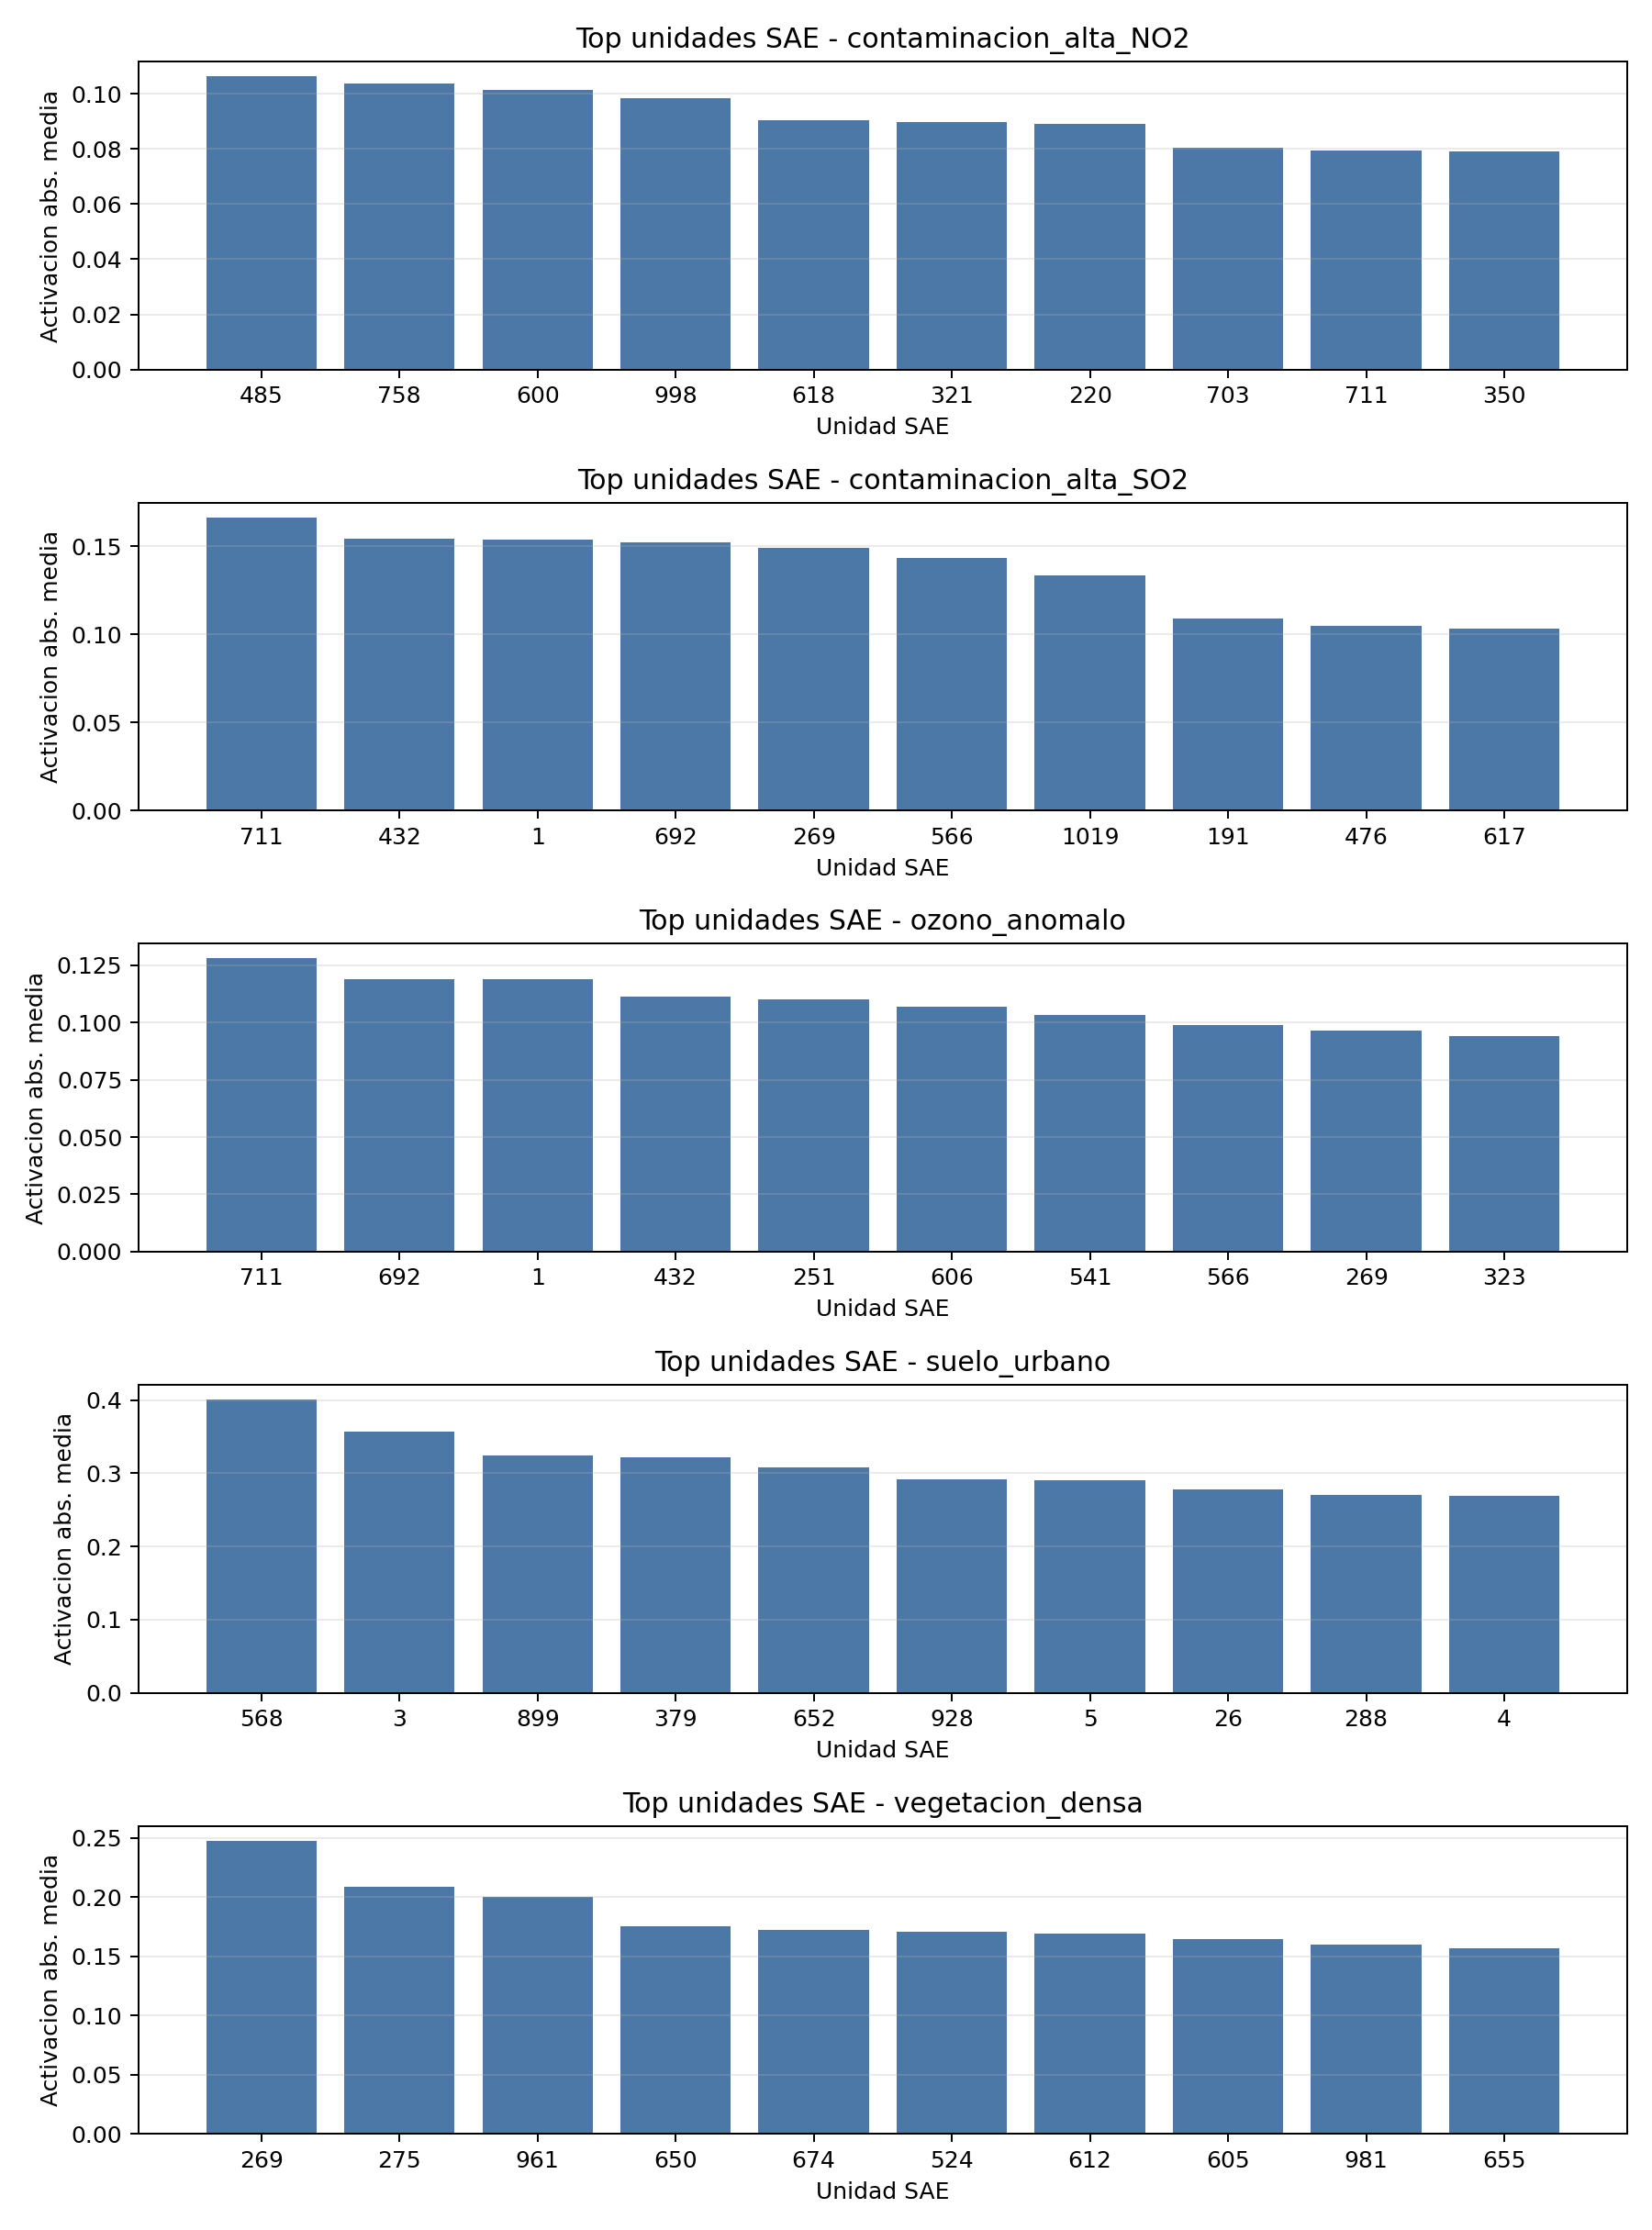

**Interpretacion.** La grafica muestra que todas las clases siguen un patron parecido: un grupo pequeno de unidades SAE concentra las activaciones mas altas y luego la importancia disminuye gradualmente. La diferencia entre clases esta en cuales unidades aparecen como mas activas y no tanto en la forma general de la distribucion. Por eso, esta figura sirve para identificar las neuronas latentes mas relevantes por clase, mas que para afirmar una separacion fuerte entre clases.

In [4]:
fig_dir = ROOT / 'sae_interpretabilidad'
classes = list(test_top['candidate_class'].drop_duplicates())
fig, axes = plt.subplots(len(classes), 1, figsize=(10, 2.7 * len(classes)))
if len(classes) == 1:
    axes = [axes]

for ax, cls in zip(axes, classes):
    sub = test_top[test_top['candidate_class'] == cls].sort_values('mean_abs_activation', ascending=False).head(10)
    labels = [str(u) for u in sub['unit']]
    ax.bar(labels, sub['mean_abs_activation'], color='#4C78A8')
    ax.set_title(f'Top unidades SAE - {cls}')
    ax.set_xlabel('Unidad SAE')
    ax.set_ylabel('Activacion abs. media')
    ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
bars_path = fig_dir / 'top_units_by_class_test_bars_generado_notebook.png'
plt.savefig(bars_path, dpi=180)
plt.close()

display(Image(filename=str(bars_path)))
display(Markdown('**Interpretacion.** La grafica muestra que todas las clases siguen un patron parecido: un grupo pequeno de unidades SAE concentra las activaciones mas altas y luego la importancia disminuye gradualmente. La diferencia entre clases esta en cuales unidades aparecen como mas activas y no tanto en la forma general de la distribucion. Por eso, esta figura sirve para identificar las neuronas latentes mas relevantes por clase, mas que para afirmar una separacion fuerte entre clases.'))


In [5]:
summary_class = (
    test_top.groupby('candidate_class')
    .agg(
        top_unit=('unit', lambda s: int(s.iloc[0])),
        top_activation=('mean_abs_activation', 'max'),
        mean_top10_activation=('mean_abs_activation', lambda s: float(s.head(10).mean())),
        mean_top10_frequency=('active_frequency', lambda s: float(s.head(10).mean())),
    )
    .reset_index()
)
display(summary_class)
display(Markdown('**Interpretacion.** Esta tabla resume para cada clase la unidad mas activa, la magnitud maxima y la frecuencia media de activacion de sus 10 unidades principales. Sirve como evidencia tabular compacta del analisis de neuronas activas SAE por clase.'))


,candidate_class,top_unit,top_activation,mean_top10_activation,mean_top10_frequency
0,contaminacion_alta_NO2,485,0.106280,0.091737,0.629545
1,contaminacion_alta_SO2,711,0.166366,0.136956,0.798000
2,ozono_anomalo,711,0.128005,0.108689,0.672000
3,suelo_urbano,568,0.400869,0.311282,0.800000
4,vegetacion_densa,269,0.247922,0.182753,0.852174


**Interpretacion.** Esta tabla resume para cada clase la unidad mas activa, la magnitud maxima y la frecuencia media de activacion de sus 10 unidades principales. Sirve como evidencia tabular compacta del analisis de neuronas activas SAE por clase.

In [6]:
pairs = pd.read_csv(ROOT / 'sae_interpretabilidad/pair_top_units.csv')
display(pairs.head(30))


,split,pair_id,candidate_class,pred_class,correct,active_units_count,top_units,top_values
0,train,v5bpair_00000,suelo_urbano,suelo_urbano,True,122,"568,3,26,899,4,411,350,288,379,140,5,375","0.579369,0.552085,0.528016,0.523801,0.503936,0.447698,0.435531,0.424782,0.418298,0.414911,0.405107,0.401368"
1,train,v5bpair_00001,vegetacion_densa,vegetacion_densa,True,122,"269,519,981,961,879,279,270,477,275,822,219,674","0.281131,0.268369,0.262030,0.257718,0.234689,0.222791,0.217142,0.214156,0.210348,0.206910,0.206483,0.204370"
2,train,v5bpair_00002,contaminacion_alta_SO2,contaminacion_alta_SO2,True,122,"711,1,476,692,758,1019,422,191,386,432,510,49","0.321720,0.312698,0.270380,0.257433,0.242355,0.234107,0.228245,0.222424,0.222033,0.220710,0.217873,0.214063"
3,train,v5bpair_00003,contaminacion_alta_SO2,contaminacion_alta_SO2,True,122,"998,49,904,496,945,721,903,1003,772,437,593,248","0.358043,0.344344,0.334002,0.254524,0.247430,0.235531,0.234686,0.231957,0.230351,0.229565,0.226836,0.224233"
4,train,v5bpair_00006,suelo_urbano,suelo_urbano,True,122,"350,4,541,5,3,745,669,899,562,317,703,411","0.337683,0.295815,0.266034,0.260103,0.256760,0.255621,0.225952,0.220480,0.219037,0.216848,0.215728,0.212912"
5,train,v5bpair_00007,ozono_anomalo,ozono_anomalo,True,122,"251,218,836,323,350,541,377,745,262,926,270,477","0.332408,0.306394,0.278885,0.277195,0.248235,0.236462,0.215660,0.213068,0.212995,0.205549,0.204170,0.202794"
6,train,v5bpair_00010,ozono_anomalo,ozono_anomalo,True,122,"541,606,182,669,270,5,388,652,1014,293,1000,402","0.341875,0.319519,0.298223,0.293009,0.267780,0.258517,0.249830,0.246705,0.231987,0.225418,0.224450,0.221252"
7,train,v5bpair_00012,ozono_anomalo,ozono_anomalo,True,122,"1,323,519,270,432,660,691,218,566,762,531,222","0.349529,0.304195,0.296226,0.292080,0.272552,0.247305,0.246934,0.227595,0.225444,0.223354,0.219003,0.214232"
8,train,v5bpair_00013,vegetacion_densa,vegetacion_densa,True,122,"524,721,897,275,848,346,952,269,98,606,463,660","0.258620,0.253327,0.252061,0.239316,0.227489,0.224667,0.222798,0.217565,0.212902,0.202501,0.199442,0.198566"
9,train,v5bpair_00014,contaminacion_alta_NO2,contaminacion_alta_NO2,True,122,"127,699,201,80,198,367,285,903,603,612,541,974","0.249552,0.230955,0.216975,0.209713,0.202686,0.194733,0.190648,0.187743,0.183504,0.180355,0.179364,0.174822"


## Matriz de Confusion por Clase

,contaminacion_alta_NO2,contaminacion_alta_SO2,ozono_anomalo,suelo_urbano,vegetacion_densa
contaminacion_alta_NO2,10,15,12,1,6
contaminacion_alta_SO2,2,18,20,2,8
ozono_anomalo,8,5,27,4,6
suelo_urbano,2,3,3,36,1
vegetacion_densa,2,5,1,0,38


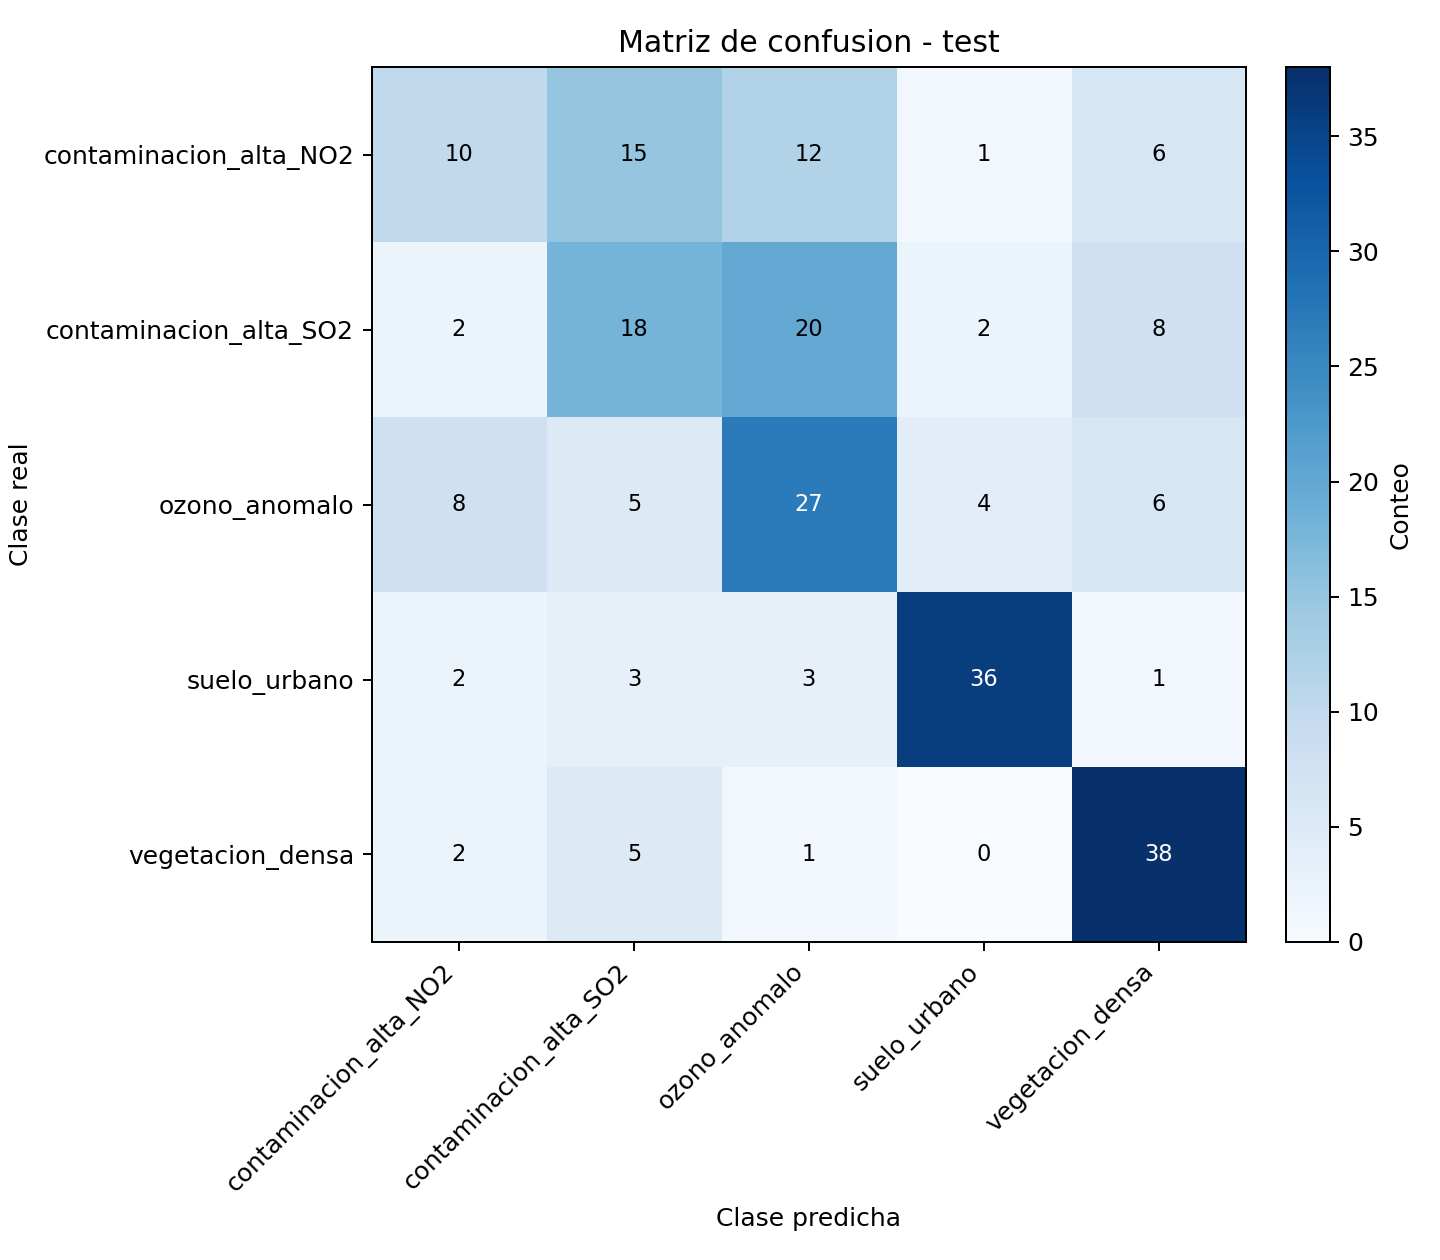

**Interpretacion.** La matriz de confusion muestra que el modelo reconoce mejor `suelo_urbano` y `vegetacion_densa`, con la mayoria de ejemplos en la diagonal. `ozono_anomalo` tambien tiene un desempeno razonable, aunque presenta confusiones con `NO2` y `SO2`. Las clases de contaminacion (`NO2` y `SO2`) son las mas dificiles de separar: varios ejemplos se confunden entre si o con `ozono_anomalo`. Esto sugiere que las clases visualmente asociadas a cobertura del suelo son mas distinguibles que las clases atmosfericas.

In [7]:
with open(ROOT / 'sae_interpretabilidad/manifest_sae_analysis.json') as f:
    manifest = json.load(f)

classes = manifest['classes']
cm = pd.DataFrame(manifest['confusion_matrices']['test'], index=classes, columns=classes)
display(cm)

plt.figure(figsize=(8, 7))
im = plt.imshow(cm.values, cmap='Blues')
plt.colorbar(im, fraction=0.046, pad=0.04, label='Conteo')
plt.xticks(range(len(classes)), classes, rotation=45, ha='right')
plt.yticks(range(len(classes)), classes)
plt.xlabel('Clase predicha')
plt.ylabel('Clase real')
plt.title('Matriz de confusion - test')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = int(cm.iloc[i, j])
        color = 'white' if value > cm.values.max() * 0.55 else 'black'
        plt.text(j, i, value, ha='center', va='center', color=color, fontsize=9)
plt.tight_layout()
cm_path = ROOT / 'sae_interpretabilidad/confusion_matrix_test_generado_notebook.png'
plt.savefig(cm_path, dpi=180)
plt.close()

display(Image(filename=str(cm_path)))
display(Markdown('**Interpretacion.** La matriz de confusion muestra que el modelo reconoce mejor `suelo_urbano` y `vegetacion_densa`, con la mayoria de ejemplos en la diagonal. `ozono_anomalo` tambien tiene un desempeno razonable, aunque presenta confusiones con `NO2` y `SO2`. Las clases de contaminacion (`NO2` y `SO2`) son las mas dificiles de separar: varios ejemplos se confunden entre si o con `ozono_anomalo`. Esto sugiere que las clases visualmente asociadas a cobertura del suelo son mas distinguibles que las clases atmosfericas.'))


## Heatmap de unidades activas por clase

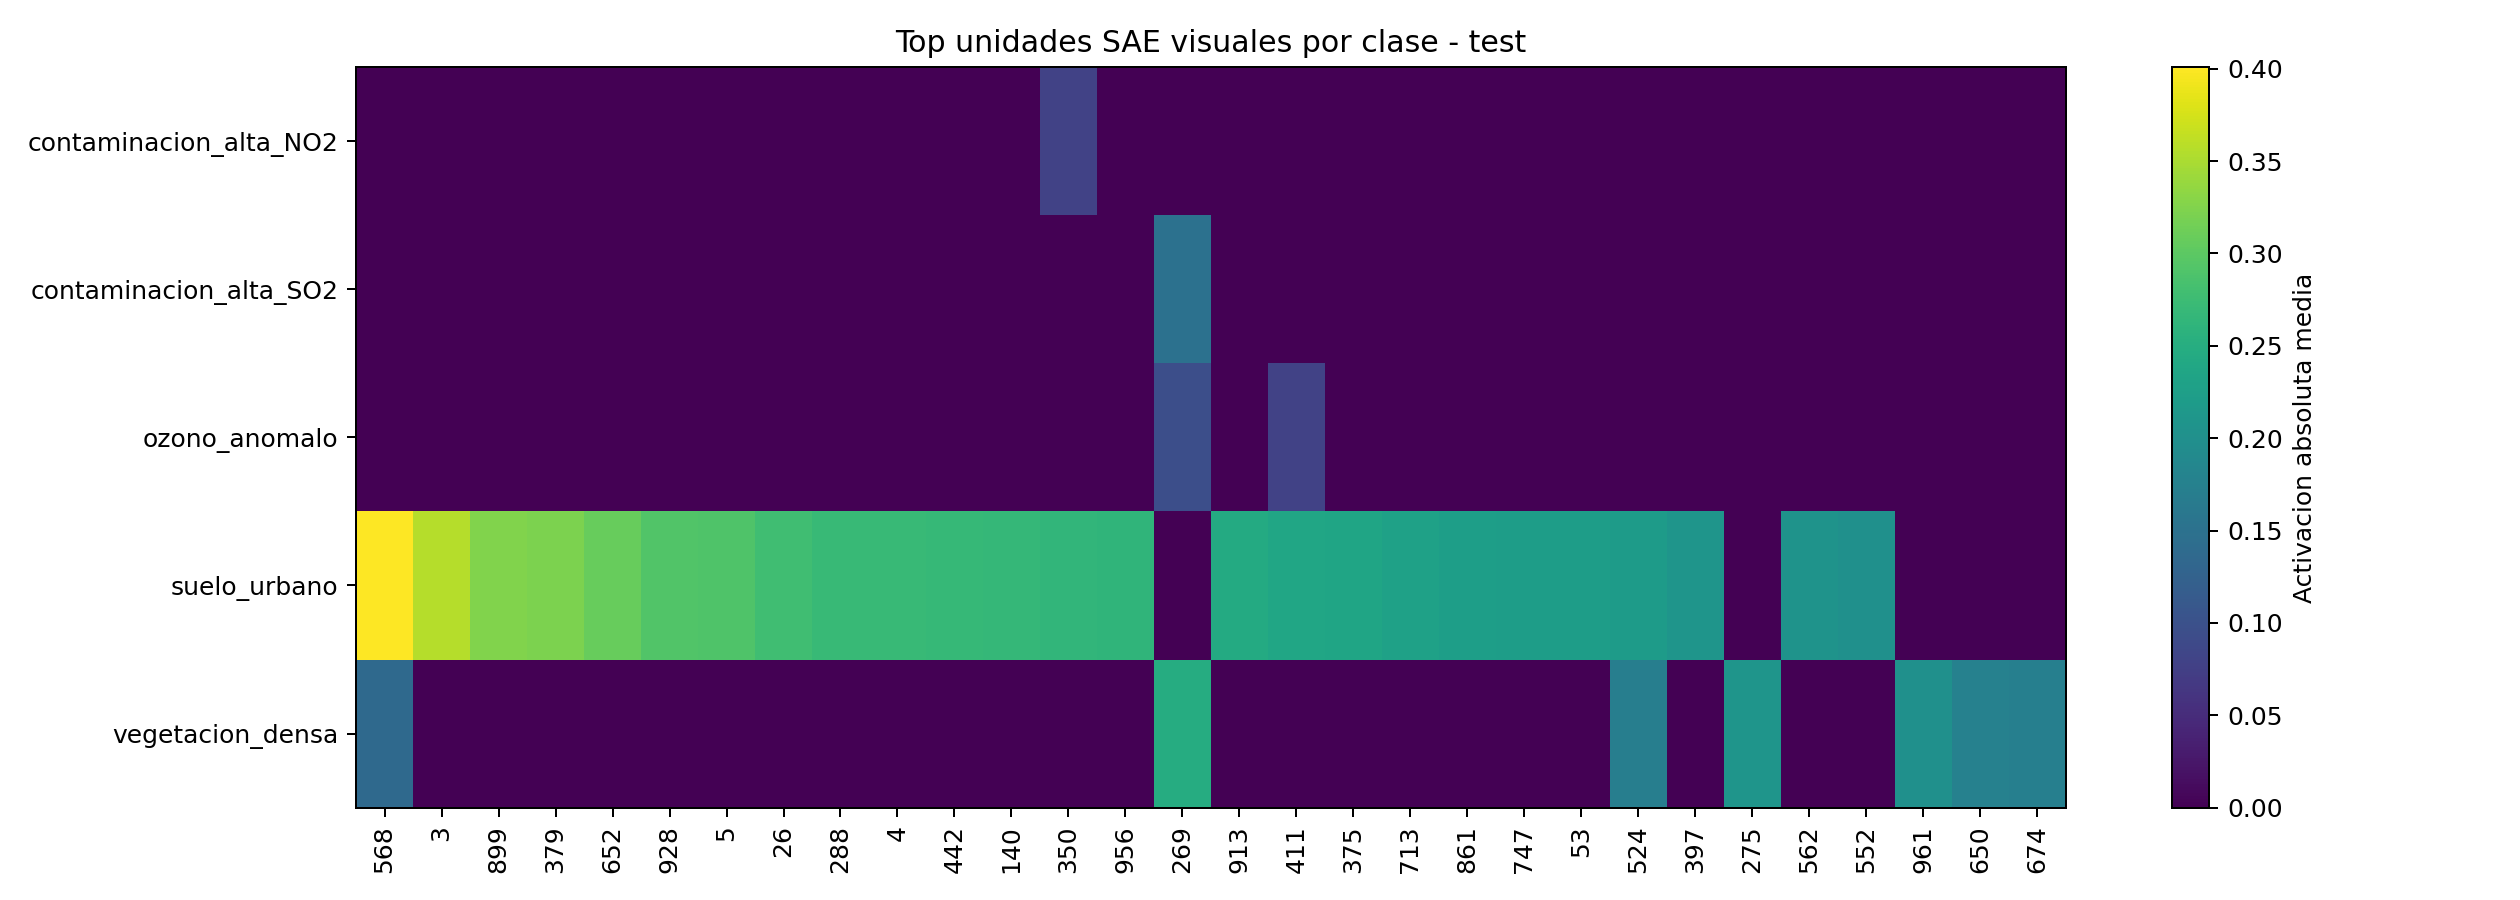

**Interpretacion.** El heatmap resume que unidades SAE aparecen con mayor activacion media por clase. `suelo_urbano` concentra los valores mas altos en varias unidades, mientras que `vegetacion_densa` activa un subconjunto diferente con menor intensidad. Las clases `NO2`, `SO2` y `ozono_anomalo` muestran senales mas debiles y localizadas. Esto ayuda a identificar que neuronas latentes participan en cada clase, pero no implica que las clases esten completamente separadas.

In [8]:
heat = test_top.pivot_table(index='candidate_class', columns='unit', values='mean_abs_activation', aggfunc='mean', fill_value=0)
keep_units = test_top.groupby('unit')['mean_abs_activation'].max().sort_values(ascending=False).head(30).index
heat = heat.reindex(columns=keep_units, fill_value=0)

plt.figure(figsize=(14, 5))
plt.imshow(heat.values, aspect='auto', cmap='viridis')
plt.colorbar(label='Activacion absoluta media')
plt.yticks(range(len(heat.index)), heat.index)
plt.xticks(range(len(heat.columns)), heat.columns, rotation=90)
plt.title('Top unidades SAE visuales por clase - test')
plt.tight_layout()
heatmap_path = ROOT / 'sae_interpretabilidad/top_units_by_class_heatmap_generado_notebook.png'
plt.savefig(heatmap_path, dpi=180)
plt.close()

display(Image(filename=str(heatmap_path)))
display(Markdown('**Interpretacion.** El heatmap resume que unidades SAE aparecen con mayor activacion media por clase. `suelo_urbano` concentra los valores mas altos en varias unidades, mientras que `vegetacion_densa` activa un subconjunto diferente con menor intensidad. Las clases `NO2`, `SO2` y `ozono_anomalo` muestran senales mas debiles y localizadas. Esto ayuda a identificar que neuronas latentes participan en cada clase, pero no implica que las clases esten completamente separadas.'))


In [9]:
display(pd.DataFrame([manifest]))


,checkpoint,dataset,embedding_npz,config,classes,reports,confusion_matrices,outputs
0,/workspace/geovision-cali-hf/outputs/clip_training_remoteclip_fusion_ksae_v10_v5b_gsplit_seed57_full_logging/seed57_k12_drop25_wd1e3_full_logging_best.pt,/workspace/geovision-cali-hf/outputs/clip_dataset_final_step_by_step/clip_s2_12band_pdf_classes_v5b_high_purity_1500_gsplit,/workspace/geovision-cali-hf/outputs/clip_training_remoteclip_v10_v5b_embeddings/embeddings_remoteclip_v10_v5b.npz,"{'name': 'seed57_k12_drop25_wd1e3_full_logging', 'k_frac': 0.12, 'l1': 0.004, 'alpha': 0.1, 'lr': 0.00015, 'wd': 0.001, 'drop': 0.25, 'epochs': 90, 'batch':...","[contaminacion_alta_NO2, contaminacion_alta_SO2, ozono_anomalo, suelo_urbano, vegetacion_densa]","{'train': {'contaminacion_alta_NO2': {'precision': 0.9855769230769231, 'recall': 0.9669811320754716, 'f1-score': 0.9761904761904762, 'support': 212.0}, 'con...","{'train': [[205, 3, 4, 0, 0], [3, 191, 6, 0, 0], [0, 3, 166, 0, 0], [0, 0, 0, 210, 0], [0, 0, 0, 0, 209]], 'val': [[15, 14, 8, 4, 3], [5, 9, 8, 10, 18], [7,...","{'split_summary': '/workspace/geovision-cali-hf/outputs/sae_analysis_v10_v5b_gsplit_seed57_full_logging/sae_split_summary.csv', 'top_units_by_class': '/work..."


## Lectura Final

La configuracion `k_frac=0.12` mantiene aproximadamente 122 unidades activas de 1024 por muestra, con sparsity test `0.8809`. El heatmap muestra una activacion especialmente fuerte y distribuida para `suelo_urbano`, activaciones mas focalizadas para `vegetacion_densa`, y senales mucho mas puntuales para las clases de contaminacion y ozono. Esta evidencia no prueba causalidad ambiental, pero si demuestra que el SAE genera una representacion compacta y auditable por clase.